<a href="https://colab.research.google.com/github/anferivera/Metodos_Computacionales/blob/main/3_4_roots_using_python_libraries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Root methos with tolerance

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import animation
from scipy import integrate
from scipy import optimize

In [ ]:
### ALL THE METHODS worked in classes

#++++++++++++++++++++++++++++++++++++++
#   Bisection Method: Simplest form
#++++++++++++++++++++++++++++++++++++++
def Bisection( f, a, b, Nmax=100, printer=False ):
    #verifying the STEP1, a and b with different signs
    if f(a)*f(b)>0:
        print("Error, f(a) and f(b) should have opposite signs")
        return False
    #Assigning the current extreme values, STEP2
    ai = a
    bi = b
    #Iterations
    n = 1
    while n<=Nmax:
        #Bisection, STEP3
        pi = (ai+bi)/2.0
        #Evaluating function in pi, STEP4 and STEP5
        if printer:
            print("Value for %d iterations:"%n,pi)
        #Condition A
        if f(pi)*f(ai)>0:
            ai = pi
        #Condition B
        elif f(pi)*f(ai)<0:
            bi = pi
        #Condition C: repeat the cycle
        n+=1
    #Final result
    return pi

#++++++++++++++++++++++++++++++++++++++
#   Fixed Point Method: Simplest form
#++++++++++++++++++++++++++++++++++++++
def FixedPoint( f, pini, Nmax):
    g = lambda x: x-f(x)
    #Iterations
    for n in range(Nmax):
        pini = g(pini)
    return pini

#++++++++++++++++++++++++++++++++++++++
#   Newton Method: Simplest form
#++++++++++++++++++++++++++++++++++++++
def NewtonRaphson( f, fp, pini, Nmax ):
    #Initial condition
    p = pini
    #Iterations
    for n in range(Nmax):
        p = p - f(p)/fp(p)
    return p

#++++++++++++++++++++++++++++++++++++++
#   Secant Method: Simplest form
#++++++++++++++++++++++++++++++++++++++
def Secant_method( f, pini1, pini2, Nmax):
    #Initial condition
    pn1 = pini1
    pn2 = pini2
    #Iterations.
    for n in range(Nmax):
        if f(pn1)-f(pn2) == 0:
          break
        p = pn1 - f(pn1)*(pn1-pn2)/(f(pn1)-f(pn2))

        pn2 = pn1
        pn1 = p

    return p

# Example: Compute the root of $f(x)$

In [ ]:
def f(x):
    return x**2-1

def df(x):
  return 2*x

In [ ]:
def f(x):
    return x - np.cos(x)

def df(x):
  return 1 + np.sin(x)

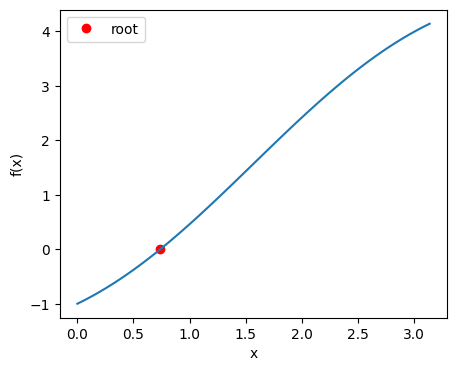

In [ ]:
plt.figure(figsize=(5,4))
x = np.linspace(0,np.pi,100)
plt.plot(Bisection(f,0,1.5),0,'ro',label='root')
plt.plot(x,f(x))
#plt.hlines(0,0,np.pi,'k')
#plt.vlines(0,np.min(f(x)),np.max(f(x)),'k')
plt.xlabel('x')
plt.ylabel('f(x)')

plt.legend(loc='best')
#plt.grid()
plt.show()

## Example: using our differentes implementations

In [ ]:
print('************ USING our methods *******************\n')
print('Bisection:    ', Bisection(f,0,1.5,20),'\n')
print('Fixed point:  ', FixedPoint(f,0.1,20),'\n')
print('NewtonRpahson:', NewtonRaphson(f,df,0.5,5),'\n')
print('Secant:       ', Secant_method(f,1.5,1.2,5),'\n')
print('*************************************************')

************ USING our methods *******************

Bisection:     0.7390837669372559 

Fixed point:   0.7389404933450101 

NewtonRpahson: 0.7390851332151607 

Secant:        0.7390851332153305 

*************************************************


## Example: using scipy and python

Let's compute the root for $f(x)$ using `scipy` library and check with:
* **optimize.bisec** :
* **optimize.fixed_point** :
* **optimize.newton** : Find a root of the scalar-valued function func given a nearby scalar starting point x0. The Newton-Raphson method is used if the derivative fprime of func is provided, otherwise the **secant** method is used.

In [ ]:
import scipy.optimize as optimize

print('************ USING csipy *************************\n')
print("Using bisect SciPy:",         optimize.bisect(f, 0, 2, xtol=1e-6),'\n')
print("Using fixed_point SciPy:",    optimize.fixed_point(f,0.5),'\n')
print("Using Newton-Raphson SciPy:", optimize.newton(f,0.5,fprime=df, tol=1e-06),'\n')
print("Using Secant SciPy:", optimize.newton(f,0.5,fprime=None, tol=1e-06),'\n')
print('**************************************************')

************ USING csipy *************************

Using bisect SciPy: 0.7390851974487305 

Using fixed_point SciPy: 29.845130209103036 

Using Newton-Raphson SciPy: 0.7390851332151607 

Using Secant SciPy: 0.7390851332151601 

**************************************************


... Warning in fixed_point ritune

## Methods with tolerance: BEST OF THE BEST!

In [ ]:
### ALL THE METHODS with TOLERANCE tol

#++++++++++++++++++++++++++++++++++++++
#   Bisection: Simplest form with tol
#++++++++++++++++++++++++++++++++++++++
def Bisection( f, a, b, tol=1e-6):
    'My Bisection method: run with tol=1e-6 by default. Return [root,n_iter]'
    #verifying a and b with different signs
    if f(a)*f(b)>0:
        print("Error, f(a) and f(b) should have opposite signs")
        return False
    #Assigning the current extreme values, STEP2
    ai = a
    bi = b
    #Iterations
    n = 1
    pi = (ai+bi)/2.0 #initial guess
    while np.abs(f(pi))>tol:
      pi = (ai+bi)/2.0 #Bisection: medium point
      #Condition A
      if f(pi)*f(ai)>0:
          ai = pi
      #Condition B
      elif f(pi)*f(ai)<0:
          bi = pi
      n+=1

    return pi,n

#++++++++++++++++++++++++++++++++++++++
#   Fixed Point Method: Simplest form with tol
#++++++++++++++++++++++++++++++++++++++
def FixedPoint( f, pini, tol=1e-2 ):
    'My Fixed point method: run with tol=1e-2 by default. Return [root,n_iter]'
    g = lambda x: x-f(x)
    #Iterations
    n=1
    while abs(f(pini))>tol:
        pini = g(pini)
        n +=1
    return pini,n

#++++++++++++++++++++++++++++++++++++++
#   Newton Method: Simplest form with tol
#++++++++++++++++++++++++++++++++++++++
def NewtonRaphson( f, fp, pini, tol=1e-6 ):
    'My Newton-Raphson method: run with tol=1e-6 by default. Return [root,n_iter]'
    p = pini #Initial condition
    #Iterations
    n = 1
    while abs(f(p))>tol:
      p = p - f(p)/fp(p)
      n +=1
    return p,n

#++++++++++++++++++++++++++++++++++++++
#   Secant Method: Simplest form with tol
#++++++++++++++++++++++++++++++++++++++
def Secant_method( f, pini1, pini2, tol=1e-6 ):
    'My Secant method: run with tol=1e-6 by default. Return [root,n_iter]'
    #Initial condition
    pn1 = pini1
    pn2 = pini2
    p = pn1
    n=1
    #Iterations.
    while abs(f(p))>tol:
      p = pn1 - f(pn1)*(pn1-pn2)/(f(pn1)-f(pn2))
      pn2 = pn1
      pn1 = p
      n +=1
    return p,n

In [ ]:
print('************ USING our methods *******************\n')
print('Bisection:    ', Bisection(f,0.1,1.5),'\n')
print('Fixed point:  ', FixedPoint(f,0.1),'\n')
print('NewtonRpahson:', NewtonRaphson(f,df,0.5),'\n')
print('Secant:       ', Secant_method(f,1.2,1.5),'\n')
print('*************************************************')

************ USING our methods *******************

Bisection:     (0.7390853881835939, 18) 

Fixed point:   (np.float64(0.7441418423459107), 12) 

NewtonRpahson: (np.float64(0.7390851339208068), 4) 

Secant:        (np.float64(0.7390851467475281), 5) 

*************************************************


Note: The fixed point works ugly!

$$\text{The end!}$$